**LOADING DATASET**

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
df=pd.read_csv(r"/content/drive/MyDrive/indian_engineering_student_placement.csv")
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


* **Description**
 **Column Name**                 | **Description**                                           |
| ------------------------------- | ----------------------------------------------------------------------- |
| **gender**                      | • Student’s gender (encoded)<br>• Used for demographic analysis         |
| **branch**                      | • Engineering specialization<br>• Impacts placement opportunities       |
| **tenth_percentage**            | • Class 10 academic score<br>• Shows early academic foundation          |
| **twelfth_percentage**          | • Class 12 performance<br>• Often used as eligibility criteria          |
| **cgpa**                        | • Overall college performance<br>• Key indicator of academic strength   |
| **backlogs**                    | • Number of failed subjects<br>• Higher value reduces placement chances |
| **internships_completed**       | • Count of internships done<br>• Shows industry exposure                |
| **projects_completed**          | • Number of projects completed<br>• Reflects practical skills           |
| **certifications_count**        | • Total certifications earned<br>• Indicates skill enhancement          |
| **coding_skill_rating**         | • Coding proficiency level<br>• Important for technical roles           |
| **aptitude_skill_rating**       | • Logical & quantitative ability<br>• Required for placement tests      |
| **communication_skill_rating**  | • Verbal and interpersonal skills<br>• Important for interviews         |
| **hackathons_participated**     | • Hackathon participation count<br>• Shows problem-solving ability      |
| **attendance_percentage**       | • Class attendance level<br>• Reflects discipline                       |
| **study_hours_per_day**         | • Daily study duration<br>• Indicates learning effort                   |
| **sleep_hours**                 | • Average sleep time<br>• Affects focus & productivity                  |
| **stress_level**                | • Stress intensity level<br>• High stress impacts performance           |
| **extracurricular_involvement** | • Non-academic participation<br>• Shows leadership & personality        |
| **part_time_job**               | • Part-time job status<br>• Indicates time management                   |
| **internet_access**             | • Internet availability<br>• Important for learning resources           |
| **family_income_level**         | • Economic background<br>• Affects access to opportunities              |


**Data shape & info()**

In [ ]:
df.shape

(5000, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

**“Our dataset did not originally contain a target variable. Therefore, we created a new target variable called placement_status, which represents whether a student is placed or not. This variable is used as the dependent variable for building and training the machine learning model.”**

In [ ]:
df["placement_status"] =((df["cgpa"] >= 6.5).astype(int) + (df["backlogs"] <= 2).astype(int) + (df["internships_completed"] >= 1).astype(int) + (df["coding_skill_rating"] >= 5).astype(int))
# 3 or more than 3 conditions true → placed
df["placement_status"] = (df["placement_status"] >= 3).astype(int)

We have two columns named **Student** **ID** and **City_Tier** that is not useful for model training, so they can be dropped.

In [ ]:
df=df.drop(columns=["Student_ID","city_tier"],axis=1)

“We observed that the **extracurricular_involvement** column in our dataset had some **missing values**. To handle this, we replaced the missing values with the **mode** of that column.
* Apart from this, all other columns are clean.

In [ ]:
df['extracurricular_involvement'].mode()

,extracurricular_involvement
0,Medium


In [ ]:
df["extracurricular_involvement"]=df["extracurricular_involvement"].fillna("Medium")

As we can see, the dataset is clean, so we will perform **EDA** now.

**Exploratory** **Data** **Analysis**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

**Overall** **Dataset** **Summary**

In [ ]:
df.describe()

,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200
std,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213
min,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000
25%,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000
50%,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000
75%,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000
max,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000


* This shows count, mean, std, min, max, and quartiles for all numerical features.

* It helps identify data range, skewness, and outliers.

* Useful for understanding overall data distribution before modeling.

First, we will analyze our **Target** column.

In [ ]:
df['placement_status'].describe()

,placement_status
count,5000.000000
mean,0.912000
std,0.283323
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


* Mean value shows overall placement ratio in the dataset.
* Placement depends on combined academic and skill factors.

In [ ]:
df["gender"].describe()


,gender
count,5000
unique,2
top,Male
freq,2999


* Both genders appear across placed and non-placed categories.
* Gender does not show strong influence on placement.

In [ ]:
df["branch"].describe()

,branch
count,5000
unique,5
top,CSE
freq,1522


* Some branches show higher placement counts.
* Branch has a moderate impact based on industry demand.

In [ ]:
df["cgpa"].mean()
df.groupby("placement_status")["cgpa"].mean()


,cgpa
placement_status,
0,6.816227
1,8.425406


* Placed students have a higher average CGPA compared to non-placed students.
* CGPA shows a strong positive relationship with placement status.

In [ ]:
df["tenth_percentage"].mean()
df.groupby("placement_status")["tenth_percentage"].mean()


,tenth_percentage
placement_status,
0,61.857500
1,75.760899


* Placed students show slightly higher 10th percentages.
* Early academic performance has a mild positive impact on placement.

In [ ]:
df["twelfth_percentage"].mean()
df.groupby("placement_status")["twelfth_percentage"].mean()


,twelfth_percentage
placement_status,
0,61.773636
1,75.775197


* Placed students have a higher average 12th percentage.
* Academic consistency positively affects placement chances.

In [ ]:
df["backlogs"].mean()
df.groupby("placement_status")["backlogs"].mean()


,backlogs
placement_status,
0,0.731818
1,0.306140


* Non-placed students have a higher average number of backlogs.
* Backlogs negatively affect placement probability.

In [ ]:
df["study_hours_per_day"].mean()
df.groupby("placement_status")["study_hours_per_day"].mean()

,study_hours_per_day
placement_status,
0,3.281591
1,4.114408


* Placed students study slightly more hours per day.
* Study hours have an indirect positive impact on placement

In [ ]:
df["attendance_percentage"].mean()
df.groupby("placement_status")["attendance_percentage"].mean()


,attendance_percentage
placement_status,
0,70.150909
1,72.223991


* Placed students have higher average attendance.
* Attendance reflects discipline and consistency.

In [ ]:
df["projects_completed"].mean()
df.groupby("placement_status")["projects_completed"].mean()

,projects_completed
placement_status,
0,4.300000
1,5.648026


* Placed students have completed more projects on average.
* Projects improve practical exposure and employability.

In [ ]:
df["internships_completed"].mean()
df.groupby("placement_status")["internships_completed"].mean()

,internships_completed
placement_status,
0,0.359091
1,2.303728


* Internships are significantly higher among placed students.
* Internships strongly support placement outcomes

In [ ]:
df["coding_skill_rating"].mean()
df.groupby("placement_status")["coding_skill_rating"].mean()

,coding_skill_rating
placement_status,
0,2.865909
1,3.811842


* Placed students have higher coding skill ratings.
* Coding skill is one of the strongest placement predictors.

In [ ]:
df["communication_skill_rating"].mean()
df.groupby("placement_status")["communication_skill_rating"].mean()

,communication_skill_rating
placement_status,
0,3.056818
1,3.022368


* Communication skills are better among placed students.
* They play a key role in interviews and HR rounds.

In [ ]:
df["aptitude_skill_rating"].mean()
df.groupby("placement_status")["aptitude_skill_rating"].mean()

,aptitude_skill_rating
placement_status,
0,3.425000
1,4.183114


* Placed students perform better in aptitude skills.
* Aptitude helps clear written placement tests.

In [ ]:
df["hackathons_participated"].mean()
df.groupby("placement_status")["hackathons_participated"].mean()

,hackathons_participated
placement_status,
0,2.861364
1,3.785526


* Placed students participate slightly more in hackathons.
* Hackathons improve problem-solving skills.

In [ ]:
df["certifications_count"].mean()
df.groupby("placement_status")["certifications_count"].mean()

,certifications_count
placement_status,
0,2.429545
1,2.875219


* Placed students have more certifications on average.
* Certifications add value but are not decisive alone.

In [ ]:
df["sleep_hours"].mean()
df.groupby("placement_status")["sleep_hours"].mean()

,sleep_hours
placement_status,
0,6.895227
1,6.960768


* Placed students maintain balanced sleep hours.
* Proper sleep supports better focus and performance.

In [ ]:
df["stress_level"].mean()
df.groupby("placement_status")["stress_level"].mean()

,stress_level
placement_status,
0,6.579545
1,5.966228


* Non-placed students show higher stress levels.
* High stress negatively affects placement preparation.

In [ ]:
df["part_time_job"].describe()
df.groupby("placement_status")["part_time_job"].describe()

,count,unique,top,freq
placement_status,,,,
0,440,2,No,353
1,4560,2,No,3654


* Part-time jobs are present in both categories.
* Excessive work may affect academics.

In [ ]:
df["family_income_level"].describe()
df.groupby("placement_status")["family_income_level"].describe()

,count,unique,top,freq
placement_status,,,,
0,440,3,Medium,220
1,4560,3,Medium,2246


* Family income level shows the socio-economic background of students.
* Both placed and non-placed students belong to different income groups.
* Placement outcomes depend more on skills and academics than family income

In [ ]:
df["internet_access"].describe()
df.groupby("placement_status")["internet_access"].describe()

,count,unique,top,freq
placement_status,,,,
0,440,2,Yes,364
1,4560,2,Yes,4097


* Most placed students have internet access.
* Internet access indirectly helps in preparation.

In [ ]:
df["extracurricular_involvement"].describe()
df.groupby("placement_status")["extracurricular_involvement"].describe()

,count,unique,top,freq
placement_status,,,,
0,440,3,Medium,212
1,4560,3,Medium,2295


* Placed students show slightly higher extracurricular involvement.
* It supports personality development.

Now, we will check **value** **counts** for each column.

In [ ]:
df["gender"].value_counts()

,count
gender,
Male,2999
Female,2001


* This shows the distribution of male and female students.
* Both genders are well represented in the dataset.
* Gender alone does not strongly influence placement.

In [ ]:
df["branch"].value_counts()

,count
branch,
CSE,1522
ECE,1336
IT,963
ME,725
CE,454


* This shows the number of students in each engineering branch.
* Some branches have higher representation due to popularity.
* Branch demand may affect placement opportunities

In [ ]:
df["cgpa"].value_counts().sort_values(ascending=False).head()

,count
cgpa,
10.00,260
8.02,31
8.71,30
7.91,28
8.42,28


* CGPA values show overall academic performance distribution.
* Higher CGPA values are less frequent but important.
* CGPA strongly influences placement outcomes.

In [ ]:
df["tenth_percentage"].value_counts().sort_values(ascending=False).head()

,count
tenth_percentage,
50.0,57
75.3,27
74.9,27
75.8,27
73.5,26


* 10th percentage values show early academic performance.
* Most students score within a common range.
* It has a mild positive effect on placement.

In [ ]:
df["twelfth_percentage"].value_counts().sort_values(ascending=False).head()

,count
twelfth_percentage,
50.0,56
78.2,29
76.3,27
70.3,27
68.0,27


* 12th percentage reflects higher secondary performance.
* Consistent scorers tend to perform better in placements.
* It moderately impacts placement

In [ ]:
df["backlogs"].value_counts()

,count
backlogs,
0,3603
1,1123
2,232
3,38
4,3
5,1


* Most students have fewer or zero backlogs.
* Higher backlogs indicate academic difficulties.
* Backlogs negatively affect placement chances.

In [ ]:
df["study_hours_per_day"].value_counts().sort_values(ascending=False).head()

,count
study_hours_per_day,
0.0,119
3.7,117
3.8,113
4.7,109
4.6,103


* This shows how much time students spend studying daily.
* Most students study a moderate number of hours.
* Higher study hours indirectly improve placement chances.

In [ ]:
df["attendance_percentage"].value_counts().sort_values(ascending=False).head()

,count
attendance_percentage,
68.1,34
73.3,33
71.7,33
69.9,33
77.1,32


* Attendance values indicate discipline and regularity.
* Higher attendance is common among placed students.
* It positively influences placement outcomes.

In [ ]:
df["projects_completed"].value_counts()

,count
projects_completed,
8,1061
7,952
6,775
5,641
4,606
3,496
2,296
1,136
0,37


* This shows the number of projects completed by students.
* More projects indicate better practical exposure.
* Students with more projects are more employable.

In [ ]:
df["internships_completed"].value_counts()

,count
internships_completed,
2,1586
3,1288
1,1055
4,643
0,428


* Many students have completed at least one internship.
* Internships provide real-world industry experience.
* They strongly improve placement probability.

In [ ]:
df["coding_skill_rating"].value_counts()

,count
coding_skill_rating,
5,1986
4,998
3,967
2,771
1,278


In [ ]:
df["communication_skill_rating"].value_counts()

,count
communication_skill_rating,
4,1044
5,1009
3,992
1,980
2,975


* This shows communication skill distribution.
* Good communication helps in interviews and HR rounds.
* It strongly affects final placement decisions.

In [ ]:
df["aptitude_skill_rating"].value_counts()

,count
aptitude_skill_rating,
4,2541
5,1549
3,854
2,55
1,1


* Aptitude ratings reflect logical and analytical ability.
* Higher aptitude helps clear placement tests.
* It has a moderate positive impact on placement

In [ ]:
df["hackathons_participated"].value_counts()

,count
hackathons_participated,
4,1113
5,1057
3,933
6,718
2,650
1,377
0,152


* This shows student participation in hackathons.
* Hackathons reflect problem-solving and innovation skills.
* They slightly enhance placement chances.

In [ ]:
df["certifications_count"].value_counts()

,count
certifications_count,
2,1108
3,1043
1,913
4,758
5,418
0,335
6,265
7,92
8,46


* Most students have a limited number of certifications.
* Certifications add value to student profiles.
* They support placement but are not sufficient alone.

In [ ]:
df["sleep_hours"].value_counts().sort_values(ascending=False).head()

,count
sleep_hours,
9.0,264
6.9,179
7.2,177
7.1,176
7.0,171


* Sleep hours show lifestyle patterns of students.
* Balanced sleep supports better focus and productivity.
* Extreme sleep patterns may reduce performance.

In [ ]:
df["stress_level"].value_counts()

,count
stress_level,
10,817
6,530
5,509
7,509
8,506
4,505
3,465
9,456
2,373


* Stress levels indicate mental pressure on students.
* Higher stress is more common among non-placed students.
* Stress negatively affects placement preparation.

In [ ]:
df["part_time_job"].value_counts()

,count
part_time_job,
No,4007
Yes,993


* Some students do part-time jobs while studying.
* Part-time work improves time management.
* Excessive work may affect academic performance.

In [ ]:
df["family_income_level"].value_counts()

,count
family_income_level,
Medium,2466
Low,1503
High,1031


In [ ]:
df["internet_access"].value_counts()

,count
internet_access,
Yes,4461
No,539


* Most students have access to the internet.
* Internet access supports learning and skill development.
* It indirectly improves placement preparation.

In [ ]:
df["extracurricular_involvement"].value_counts()

,count
extracurricular_involvement,
Medium,2507
Low,1485
High,1008


* This shows participation in extracurricular activities.
* Such activities help in personality development.
* They provide a slight advantage during interviews.

In [ ]:
df["placement_status"].value_counts()

,count
placement_status,
1,4560
0,440


* This shows the number of placed and non-placed students.
* It indicates class balance in the dataset.
* Placement status depends on combined academic and skill factors.

**EDA**(Plots), **Graphical** **visualizations** for stronger justification and insights.

**CGPA Distribution**

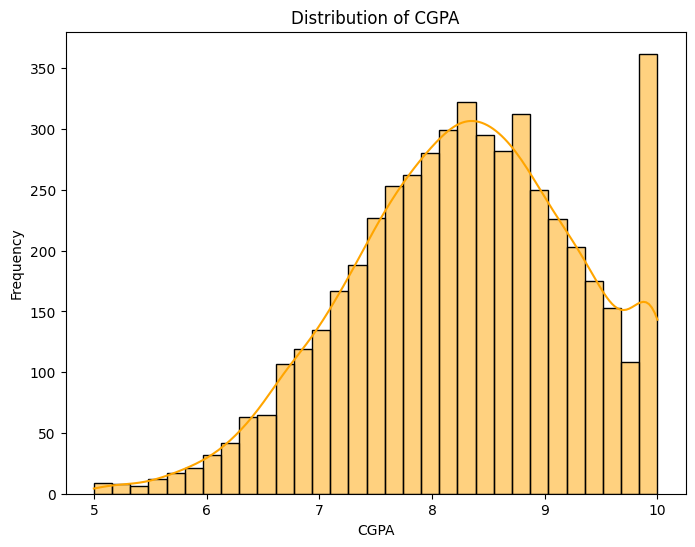

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df["cgpa"],kde=True,color="orange")
plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()


* CGPA values are mostly concentrated in the mid range.
* Very high CGPA students are comparatively fewer.

**Average** **CGPA** **vs** **Placement** **Status**

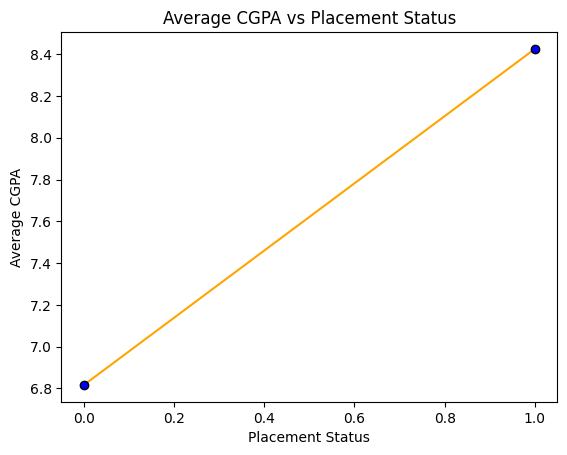

In [ ]:
df.groupby("placement_status")["cgpa"].mean().plot(kind="line", marker="o",color='orange',markerfacecolor='blue',markeredgecolor='black')
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")
plt.title("Average CGPA vs Placement Status")
plt.show()

* Placed students have a higher average CGPA.
* CGPA shows a strong positive impact on placement.
* Academic performance is a key selection factor.

**Part-Time** **job** **Distribution**

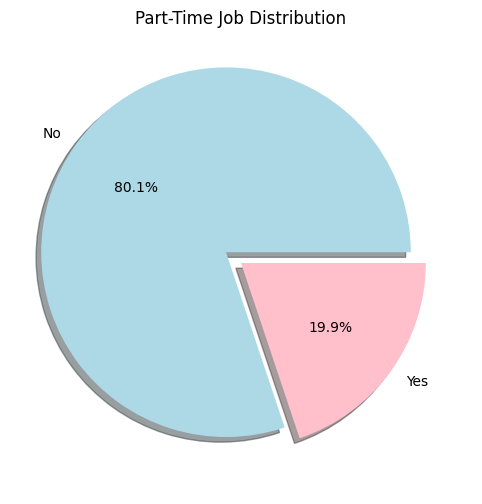

In [ ]:
plt.figure(figsize=(8,6))
explode=(0.1,0)
colors=('lightblue','pink')
df["part_time_job"].value_counts().plot.pie(autopct="%1.1f%%",shadow=True,textprops={"fontsize":10},explode=explode,colors=colors)
plt.ylabel("")
plt.title("Part-Time Job Distribution")
plt.show()

**Gender** **Distribution**

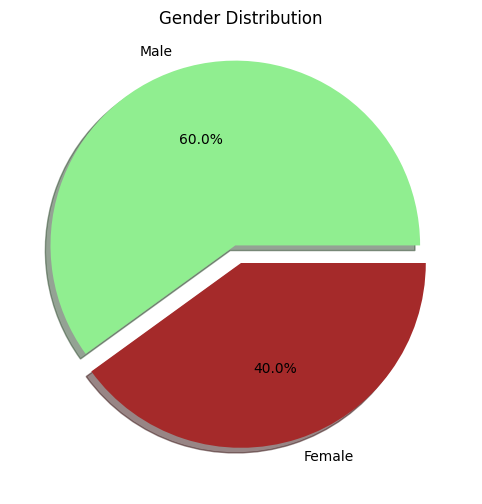

In [ ]:
plt.figure(figsize=(8,6))
explode=(0.1,0)
colors=('lightgreen','brown')
df["gender"].value_counts().plot.pie(autopct="%1.1f%%",shadow=True,textprops={"fontsize":10},explode=explode,colors=colors)
plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

* Both genders are well represented.
* Gender distribution is balanced.
* Gender does not strongly influence placement

**Placement** **Status** **Distribution**

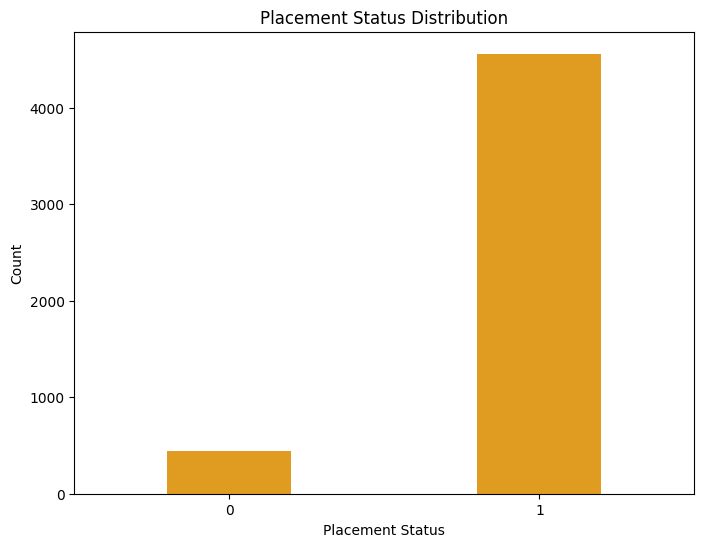

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x="placement_status", data=df,width=0.4,color="orange")
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.title("Placement Status Distribution")
plt.show()


* Shows distribution of placed vs non-placed students.
* Helps understand class balance.

**Extracurricular** **Involvement** **Distribution**

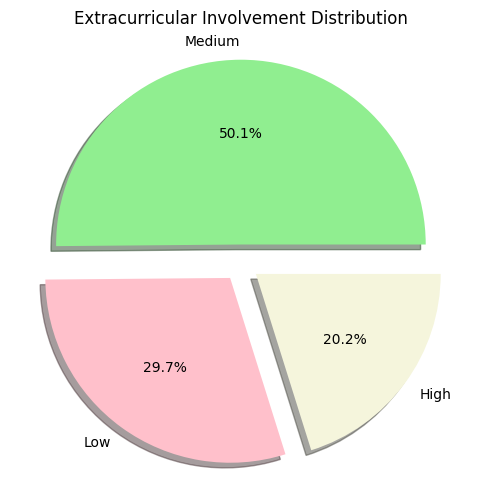

In [ ]:
plt.figure(figsize=(8,6))
explode=(0.1,0.1,0.1)
colors=('lightgreen','pink','beige')
df["extracurricular_involvement"].value_counts().plot.pie(autopct="%1.1f%%",shadow=True,textprops={"fontsize":10},explode=explode,colors=colors)
plt.ylabel("")
plt.title("Extracurricular Involvement Distribution")
plt.show()

* Many students participate in extracurricular activities.
* These activities support personality development.
* They provide a slight interview advantage.

**Internships** **vs** **Placement** **Status**(Outliers Detection)

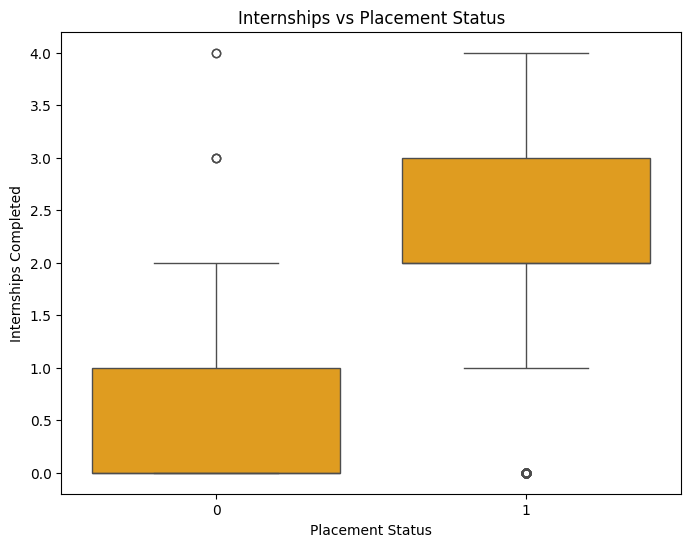

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x="placement_status",y="internships_completed",data=df,color="orange")
plt.xlabel("Placement Status")
plt.ylabel("Internships Completed")
plt.title("Internships vs Placement Status")
plt.show()

* Placed students complete more internships.
* Internships reduce placement risk.
* Practical exposure improves employability.

**Study** **Hours** **Distribution** **vs** **Placement** **Status**

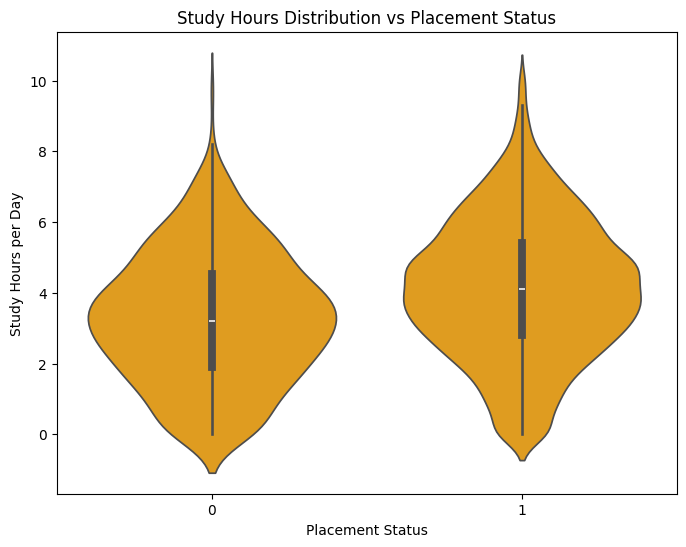

In [ ]:
plt.figure(figsize=(8,6))
sns.violinplot(x="placement_status", y="study_hours_per_day", data=df,color="orange")
plt.xlabel("Placement Status")
plt.ylabel("Study Hours per Day")
plt.title("Study Hours Distribution vs Placement Status")
plt.show()


* Placed students study slightly more on average.
* Extremely low study hours appear mostly in non-placed group.
* Consistency matters more than extreme effort.

**Internet** **Access** **Distribution**

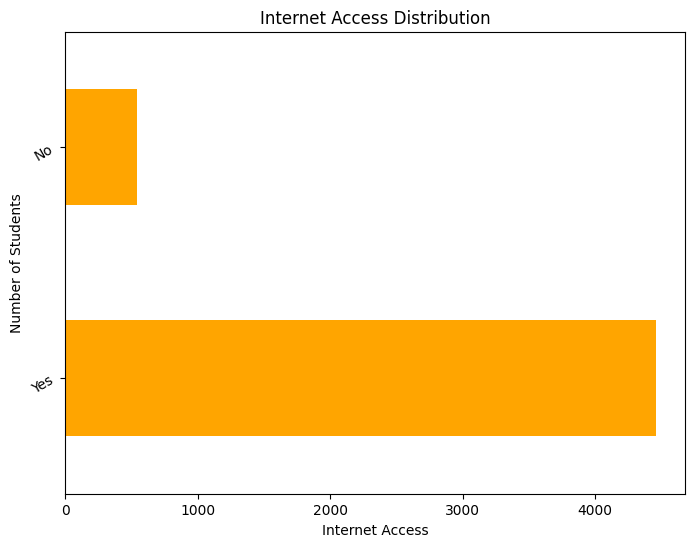

In [ ]:
plt.figure(figsize=(8,6))
df["internet_access"].value_counts().plot(kind="barh",color="orange")
plt.xlabel("Internet Access")
plt.ylabel("Number of Students")
plt.yticks(rotation=30)
plt.title("Internet Access Distribution")
plt.show()


* Internet access is available to the majority of students.
* Students with internet access have better opportunities for online learning and placement preparation.
* Lack of internet access may limit skill development and resource availability.

**Encoding**

“In our dataset, some columns such as **gender**, **branch**, **part_time_job**, **family_income_level**, **internet_access**, and **extracurricular_involvement** are categorical variables, and require encoding. All other columns are numerical variables, so encoding is not required for them.”

The first column is **gender**, on which we apply **label** **encoding** since it is a **binary** **categorical** **variable**.

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder1=LabelEncoder()
df['gender']=encoder1.fit_transform(df['gender'])

Next column is **branch**, we will apply again **label** **encoding** here.

In [ ]:
encoder2=LabelEncoder()
df['branch']=encoder2.fit_transform(df['branch'])

The **part_time_job** variable is a categorical feature and is transformed using **label** **encoding**.

In [ ]:
encoder3=LabelEncoder()
df['part_time_job']=encoder3.fit_transform(df['part_time_job'])

The **internet_access** column is categorical, so **label** **encoding** is applied.

In [ ]:
encoder4=LabelEncoder()
df['internet_access']=encoder4.fit_transform(df['internet_access'])

The next column is **family_income_level**.

we will apply **ordinal** **encoding** here because it follows hierarchical order.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
encoder5=OrdinalEncoder(categories=[["Low","Medium","High"]])
w=encoder5.fit_transform(df[["family_income_level"]])
w

array([[1.],
       [1.],
       [0.],
       ...,
       [0.],
       [1.],
       [0.]])

In [ ]:
df["family_income_level"]=df["family_income_level"].map({"Low":0,"Medium":1,"High":2})

The next column is **extracurricular_involvement**.

Again we will apply **ordinal** **encoding** because of hierarchical order.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
encoder6=OrdinalEncoder(categories=[["Low","Medium","High"]])
b=encoder6.fit_transform(df[["extracurricular_involvement"]])
b

array([[1.],
       [0.],
       [2.],
       ...,
       [1.],
       [2.],
       [2.]])

In [ ]:
df["extracurricular_involvement"]=df["extracurricular_involvement"].map({"Low":0,"Medium":1,"High":2})

From here, we will separate **Independent** and **Dependent** variables.

In [ ]:
x=df.drop(columns=["placement_status"])
y=df["placement_status"]

**Scaling** :

So, that all features are brought to the same scale.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
scale=StandardScaler()

In [ ]:
x=scale.fit_transform(x)

Splitting Dataset into training and testing data.

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

Here we are going to import the libraries required to perform **Artifical Neural Network** (**ANN**)

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
model=Sequential()

In [ ]:
from tensorflow.keras.layers import Dense,Dropout

* The layer acts as the input layer and the first hidden layer of the ANN.
* It receives input features and uses ReLU activation to learn patterns.

In [ ]:
model.add(Dense(units=8,activation="relu",input_shape=(x_train.shape[1],))) # units=no.of neurons
model.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* The layer acts as the second hidden layer of the ANN.

* It receives input features and uses ReLU activation to learn patterns.

In [ ]:
print(x_train.shape)

(4000, 21)


This code prints the shape of the training data.

In [ ]:
print(x_train.shape[1])

21


* This line prints the number of input features in the training data.

* It is used to define the input size for the ANN model.


In [ ]:
model.add(Dense(units=4,activation="relu"))
from tensorflow.keras.callbacks import EarlyStopping
early=EarlyStopping(patience=5,monitor="val_loss",restore_best_weights=True)

* This layer is a hidden layer with 4 neurons.

* ReLU activation helps the model learn deeper patterns from the data.

* Early stopping is used to stop training when validation performance stops improving, in order to prevent overfitting.


In [ ]:
model.add(Dense(units=1,activation="sigmoid"))

* This is the output layer of the ANN with one neuron.

* Sigmoid activation gives the predicted exam score in the range 0 to 1.

In [ ]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

* This step compiles the ANN model.

* This line compiles the model using the Adam optimizer, binary cross-entropy loss for binary classification, and accuracy as the evaluation metric.

In [ ]:
h=model.fit(x_train,y_train,epochs=30,validation_data=(x_test,y_test))

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0838 - loss: 0.5417 - val_accuracy: 0.0960 - val_loss: 0.2856
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0888 - loss: 0.2245 - val_accuracy: 0.0960 - val_loss: 0.0999
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0901 - loss: 0.1016 - val_accuracy: 0.0960 - val_loss: 0.0662
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0786 - loss: 0.0777 - val_accuracy: 0.0960 - val_loss: 0.0595
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0883 - loss: 0.0701 - val_accuracy: 0.0960 - val_loss: 0.0576
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0867 - loss: 0.0692 - val_accuracy: 0.0960 - val_loss: 0.0566
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0900 - loss: 0.0669 - val_accuracy: 0.0960 - val_loss: 0.0560
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0853 - loss: 0.0648 - val_accuracy: 0.

* This line trains the ANN model using the training data.

* Validation data is used to check the model’s performance during training.


In [ ]:
t_l=h.history["loss"]
v_l=h.history["val_loss"]

* These lines store the training loss and validation loss values.

* They are used to analyze how the model performance changes over epochs.


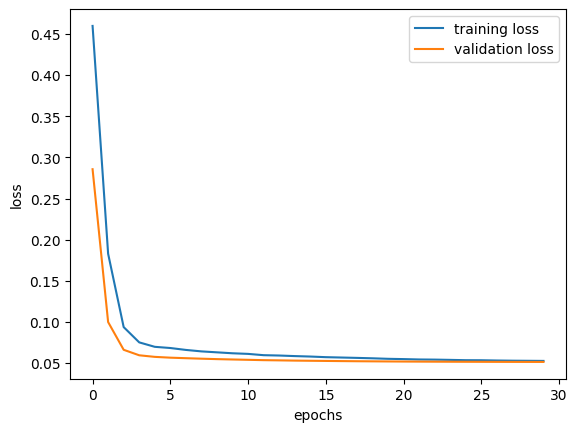

In [ ]:
import matplotlib.pyplot as plt
plt.plot(t_l,label="training loss")
plt.plot(v_l,label="validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

* This code plots the training and validation loss graph.
* It helps to visualize how the model is learning over different epochs.

 **plot**:

* This graph shows the training loss and validation loss over different epochs.
* Both losses decrease and remain close, indicating that the ANN model is learning well without overfitting.



Now we will take input from the user and generate predictions.

In [ ]:
gender=input("Enter your gender (Male/Female): ")
branch=input("Enter your branch (CSE/ECE/IT/ME/CE): ")
cgpa=float(input("Enter the cgpa (out of 10.0 ): "))
tenth_percentage=float(input("Enter the tenth_percentage (out of 100.0): "))
twelfth_percentage=float(input("Enter the twelfth_percentage (out of 100.0 ): "))
backlogs=int(input("Enter your backlogs (out of 5): "))
study_hours_per_day=float(input("Enter your study_hours_per_day (out of 10.0): "))
attendance_percentage=float(input("Enter your attendance_percentage (out of 99.2): "))
projects_completed=int(input("Enter your projects_completed (out of 8): "))
internships_completed=int(input("Enter your internships_completed (out of 4): "))
coding_skill_rating=int(input("Enter your coding_skill_rating (out of 5): "))
communication_skill_rating=int(input("Enter your communication_skill_rating (out of 5): "))
aptitude_skill_rating=int(input("Enter your aptitude_skill_rating (out of 5): "))
hackathons_participated=int(input("Enter your hackathons_participated (out of 6): "))
certifications_count=int(input("Enter your certifications_count (out of 9 ): "))
sleep_hours=float(input("Enter your sleep_hours (out of 9.0): "))
stress_level=int(input("Enter your stress_level (out of 10 ): "))
part_time_job=input("Enter your part_time_job (Yes/No): ")
family_income_level=input("Enter your family_income_level (Low/Medium/High): ")
internet_access=input("Enter your internet_access (Yes/No): ")
extracurricular_involvement=input("Enter your extracurricular_involvement (Low/Medium/High): ")

if  gender=="male":
    gender=0
elif gender=="female":
    gender=1
else:
  print("Invalid Output")

if branch=="cse":
    branch=0
elif branch=="ece":
    branch=1
elif branch=="it":
    branch=2
elif branch=="me":
    branch=3
elif branch=="ce":
    branch=4
else:
  print("Invalid Output")

if part_time_job=="yes":
    part_time_job=0
elif part_time_job=="no":
    part_time_job=1
else:
  print("Invalid Output")


if family_income_level=="low":
    family_income_level=0
elif family_income_level=="medium":
    family_income_level=1
elif family_income_level=="high":
    family_income_level=2
else:
  print("Invalid Output")

if internet_access=="yes":
    internet_access=0
elif internet_access=="no":
    internet_access=1
else:
  print("Invalid Output")

if extracurricular_involvement=="low":
    extracurricular_involvement=0
elif extracurricular_involvement=="medium":
    extracurricular_involvement=1
elif extracurricular_involvement=="high":
    extracurricular_involvement=2
else:
  print("Invalid Output")

Enter your gender (Male/Female): male
Enter your branch (CSE/ECE/IT/ME/CE): cse
Enter the cgpa (out of 10.0 ): 9.4
Enter the tenth_percentage (out of 100.0): 88.4
Enter the twelfth_percentage (out of 100.0 ): 94.4
Enter your backlogs (out of 5): 0
Enter your study_hours_per_day (out of 10.0): 8.9
Enter your attendance_percentage (out of 99.2): 78.8
Enter your projects_completed (out of 8): 6
Enter your internships_completed (out of 4): 3
Enter your coding_skill_rating (out of 5): 3
Enter your communication_skill_rating (out of 5): 4
Enter your aptitude_skill_rating (out of 5): 3
Enter your hackathons_participated (out of 6): 3
Enter your certifications_count (out of 9 ): 7
Enter your sleep_hours (out of 9.0): 9.9
Enter your stress_level (out of 10 ): 3
Enter your part_time_job (Yes/No): no
Enter your family_income_level (Low/Medium/High): medium
Enter your internet_access (Yes/No): yes
Enter your extracurricular_involvement (Low/Medium/High): low


In [ ]:
import numpy as np
x=np.array([[gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,internet_access,extracurricular_involvement]])

In [ ]:
x=scale.transform(x)
pred=model.predict(x)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
[[0.01299401]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
